# IBM Watsonx AutoAI — Equivalente Local (Open-Source)

## Objetivo Acadêmico

Este notebook replica a funcionalidade do **IBM Watsonx AutoAI** utilizando ferramentas 100% open-source que rodam localmente, sem necessidade de credenciais cloud ou conexão com internet.

### O que é o Watsonx AutoAI?

O AutoAI do IBM Watsonx é um serviço cloud que automatiza o pipeline de Machine Learning:
1. **Pré-processamento automático** — limpeza, encoding, normalização
2. **Seleção de algoritmos** — testa múltiplos modelos (XGBoost, LightGBM, Snap ML, etc.)
3. **Otimização de hiperparâmetros** — busca bayesiana automática
4. **Ensemble e Stacking** — combina os melhores modelos
5. **Ranking de pipelines** — ordena por métrica de performance

### Equivalentes Open-Source Utilizados

| Componente Watsonx | Alternativa Local |
|---|---|
| AutoAI Pipeline | **TPOT** (Tree-based Pipeline Optimization Tool) |
| AutoML com tuning | **FLAML** (Fast Lightweight AutoML) |
| AutoML completo | **PyCaret** |
| Tracking de experimentos | **MLflow** (local) |
| Snap ML | **scikit-learn** (mesmos algoritmos) |

### Dataset

**Boston Housing Price Prediction** — O mesmo dataset utilizado no notebook original do Watsonx.
- 506 amostras, 13 features numéricas
- Target: `MEDV` (valor mediano das casas em $1000s)
- Tipo: Regressão

---

In [1]:
# =============================================================================
# SETUP — Instalação e imports
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# Modelos individuais (equivalentes ao que o AutoAI testa)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, AdaBoostRegressor
)
from sklearn.svm import SVR

# AutoML frameworks (equivalentes ao Watsonx AutoAI)
try:
    from flaml import AutoML as FLAMLAutoML
    FLAML_AVAILABLE = True
except ImportError:
    FLAML_AVAILABLE = False
    print('FLAML não instalado. pip install flaml')

try:
    from tpot import TPOTRegressor
    TPOT_AVAILABLE = True
except ImportError:
    TPOT_AVAILABLE = False
    print('TPOT não instalado. pip install tpot')

try:
    import mlflow
    import mlflow.sklearn
    MLFLOW_AVAILABLE = True
except ImportError:
    MLFLOW_AVAILABLE = False
    print('MLflow não instalado. pip install mlflow')

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Setup completo.')
print(f'  FLAML disponível: {FLAML_AVAILABLE}')
print(f'  TPOT disponível: {TPOT_AVAILABLE}')
print(f'  MLflow disponível: {MLFLOW_AVAILABLE}')

Setup completo.
  FLAML disponível: True
  TPOT disponível: True
  MLflow disponível: True


## 1. Carregamento e Análise Exploratória dos Dados

O dataset Boston Housing é carregado diretamente do OpenML (mesma fonte que o Watsonx utiliza).

### Fundamentação Teórica

O dataset Boston Housing contém informações sobre 506 setores censitários de Boston. Cada amostra possui 13 atributos numéricos que descrevem características demográficas, ambientais e imobiliárias:

| Feature | Descrição |
|---|---|
| `CRIM` | Taxa de criminalidade per capita |
| `ZN` | Proporção de terrenos residenciais zoneados |
| `INDUS` | Proporção de acres comerciais não-varejistas |
| `CHAS` | Variável dummy do rio Charles (1 se limita) |
| `NOX` | Concentração de óxidos de nitrogênio |
| `RM` | Média de quartos por habitação |
| `AGE` | Proporção de unidades ocupadas construídas antes de 1940 |
| `DIS` | Distância ponderada a 5 centros de emprego |
| `RAD` | Índice de acessibilidade a rodovias radiais |
| `TAX` | Taxa de imposto sobre propriedade por $10.000 |
| `PTRATIO` | Proporção aluno-professor |
| `B` | 1000(Bk - 0.63)^2 onde Bk é proporção de afrodescendentes |
| `LSTAT` | % da população de baixa renda |
| `MEDV` | **Target** — Valor mediano das casas em $1000s |

In [2]:
# Carregar dataset Boston Housing
boston = fetch_openml(name='boston', version=1, as_frame=True, parser='auto')
df = boston.frame

# Separar features e target
X = df.drop('MEDV', axis=1).astype(float)
y = df['MEDV'].astype(float)

print(f'Dataset: {X.shape[0]} amostras, {X.shape[1]} features')
print(f'Target (MEDV): min={y.min():.1f}, max={y.max():.1f}, media={y.mean():.1f}, std={y.std():.1f}')
print()
print('Estatísticas descritivas:')
X.describe().round(2)

Dataset: 506 amostras, 13 features
Target (MEDV): min=5.0, max=50.0, media=22.5, std=9.2

Estatísticas descritivas:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97


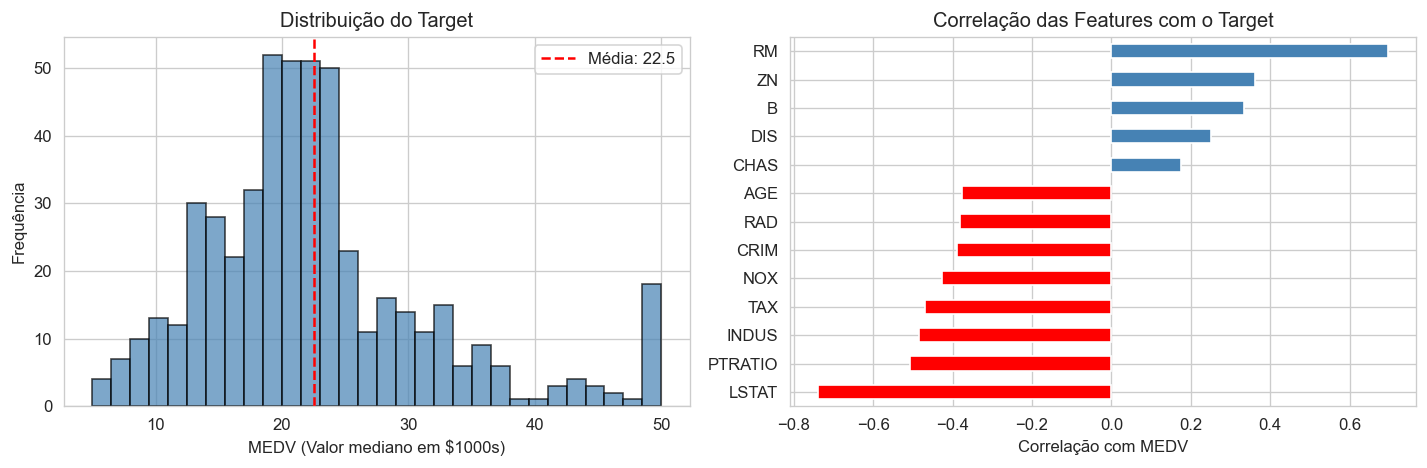

Salvo: boston_eda.png


In [3]:
# Visualização da distribuição do target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('MEDV (Valor mediano em $1000s)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do Target')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Média: {y.mean():.1f}')
axes[0].legend()

# Correlação com target
correlations = X.assign(MEDV=y).corr()['MEDV'].drop('MEDV').sort_values()
correlations.plot(kind='barh', ax=axes[1], color=['red' if v < 0 else 'steelblue' for v in correlations])
axes[1].set_xlabel('Correlação com MEDV')
axes[1].set_title('Correlação das Features com o Target')

plt.tight_layout()
plt.savefig('boston_eda.png', bbox_inches='tight', dpi=150)
plt.show()
print('Salvo: boston_eda.png')

In [4]:
# Split train/test (mesmo holdout_size=0.1 do Watsonx)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=RANDOM_STATE
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste: {X_test.shape[0]} amostras')
print(f'Proporção holdout: {X_test.shape[0]/len(X)*100:.1f}%')

Treino: 455 amostras
Teste: 51 amostras
Proporção holdout: 10.1%


## 2. Baseline — Modelos Individuais (scikit-learn)

Antes de usar AutoML, estabelecemos baselines com modelos individuais. Isso equivale à primeira etapa do AutoAI, onde múltiplos algoritmos são testados.

### Fundamentação Teórica

O Watsonx AutoAI testa internamente os seguintes algoritmos:
- **Ridge/Lasso/ElasticNet** — Regressão linear regularizada
- **Random Forest** — Ensemble de árvores com bagging
- **Gradient Boosting / XGBoost / LightGBM** — Ensemble com boosting
- **Snap ML** — Implementação otimizada da IBM (equivalente ao scikit-learn)

Aqui reproduzimos essa etapa usando scikit-learn diretamente.

In [5]:
# Definir modelos baseline (equivalentes ao que o AutoAI testa)
baseline_models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'SVR': SVR(kernel='rbf', C=1.0),
}

baseline_results = []

for name, model in baseline_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0
    
    y_pred = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    
    baseline_results.append({
        'Modelo': name,
        'RMSE (Teste)': rmse,
        'MAE (Teste)': mae,
        'R² (Teste)': r2,
        'RMSE (CV 5-fold)': cv_rmse,
        'Tempo (s)': train_time
    })
    
    print(f'{name:25s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  CV_RMSE={cv_rmse:.4f}  ({train_time:.2f}s)')

df_baseline = pd.DataFrame(baseline_results).sort_values('RMSE (Teste)')
print(f'\nMelhor baseline: {df_baseline.iloc[0]["Modelo"]} (RMSE={df_baseline.iloc[0]["RMSE (Teste)"]:.4f})')

Ridge                      RMSE=3.8683  MAE=2.8295  R²=0.7603  CV_RMSE=4.9223  (0.00s)
Lasso                      RMSE=3.8874  MAE=2.8264  R²=0.7580  CV_RMSE=4.9545  (0.00s)
ElasticNet                 RMSE=3.8424  MAE=2.7921  R²=0.7635  CV_RMSE=4.9527  (0.00s)


Random Forest              RMSE=3.0231  MAE=1.8822  R²=0.8536  CV_RMSE=3.4582  (6.17s)


Extra Trees                RMSE=2.3333  MAE=1.7463  R²=0.9128  CV_RMSE=3.2014  (3.03s)


Gradient Boosting          RMSE=2.2521  MAE=1.7832  R²=0.9188  CV_RMSE=3.1976  (2.33s)


AdaBoost                   RMSE=2.8251  MAE=2.4428  R²=0.8722  CV_RMSE=3.9874  (1.46s)


SVR                        RMSE=4.1068  MAE=2.3973  R²=0.7299  CV_RMSE=5.5473  (0.04s)

Melhor baseline: Gradient Boosting (RMSE=2.2521)


## 3. FLAML — Fast Lightweight AutoML

### O que é FLAML?

FLAML (Fast Lightweight AutoML) é um framework da Microsoft que utiliza **Cost-Aware Bayesian Optimization** para encontrar o melhor modelo e hiperparâmetros de forma eficiente. Diferente do TPOT (que usa algoritmos genéticos), FLAML:

- Usa uma função de custo para priorizar modelos rápidos
- Suporta constrained optimization (tempo máximo, orçamento)
- É significativamente mais rápido que frameworks baseados em busca exaustiva

### Equivalência com Watsonx AutoAI

O FLAML executa as mesmas etapas que o AutoAI:
1. **Seleção de algoritmos** — testa Ridge, Lasso, RF, XGBoost, LightGBM, etc.
2. **Tuning de hiperparâmetros** — otimização bayesiana cost-aware
3. **Seleção do melhor pipeline** — ranking por métrica

In [6]:
if FLAML_AVAILABLE:
    flaml_automl = FLAMLAutoML()
    
    t0 = time.time()
    flaml_automl.fit(
        X_train, y_train,
        task='regression',
        metric='rmse',
        time_budget=120,  # 2 minutos máximo
        log_file_name='flaml_boston.log',
        verbose=0,
        seed=RANDOM_STATE
    )
    flaml_time = time.time() - t0
    
    y_pred_flaml = flaml_automl.predict(X_test)
    flaml_rmse = np.sqrt(mean_squared_error(y_test, y_pred_flaml))
    flaml_mae = mean_absolute_error(y_test, y_pred_flaml)
    flaml_r2 = r2_score(y_test, y_pred_flaml)
    
    print(f'=== FLAML AutoML ===')
    print(f'Melhor modelo: {flaml_automl.best_estimator}')
    print(f'RMSE (Teste): {flaml_rmse:.4f}')
    print(f'MAE (Teste): {flaml_mae:.4f}')
    print(f'R² (Teste): {flaml_r2:.4f}')
    print(f'Tempo: {flaml_time:.2f}s')
    print(f'\nHiperparâmetros ótimos:')
    for k, v in flaml_automl.best_config.items():
        print(f'  {k}: {v}')
else:
    print('FLAML não disponível. Instale com: pip install flaml')

=== FLAML AutoML ===
Melhor modelo: catboost
RMSE (Teste): 2.4825
MAE (Teste): 1.8324
R² (Teste): 0.9013
Tempo: 121.34s

Hiperparâmetros ótimos:
  early_stopping_rounds: 19
  learning_rate: 0.12450093836156491
  n_estimators: 8192


## 4. TPOT — Tree-based Pipeline Optimization Tool

### O que é TPOT?

TPOT é um framework de AutoML que utiliza **Algoritmos Genéticos** para otimizar pipelines de Machine Learning. Ele:

1. **Representa pipelines como árvores** — operadores (scalers, feature selectors, modelos) são nós
2. **Evolui a população** — crossover e mutação entre pipelines
3. **Avalia por fitness** — RMSE, R², etc.
4. **Converge para o ótimo** — após N gerações

### Vantagens sobre Busca Bayesiana

- **Explora mais espaço** — mutações criam combinações inesperadas
- **Feature engineering automático** — TPOT pode criar features derivadas
- **Interpretabilidade** — o pipeline final é exportável como código Python

### Limitações

- **Mais lento** — algoritmos genéticos requerem muitas gerações
- **Menos determinístico** — resultados variam entre execuções
- **Overfitting possível** — sem early stopping adequado

In [7]:
if TPOT_AVAILABLE:
    tpot = TPOTRegressor(
        generations=20,
        population_size=20,
        offspring_size=10,
        mutation_rate=0.9,
        crossover_rate=0.1,
        scoring='neg_mean_squared_error',
        cv=5,
        random_state=RANDOM_STATE,
        verbosity=1,
        n_jobs=-1,
        max_time_mins=2,  # 2 minutos máximo
        config_dict='TPOT light'  # Configuração leve para datasets pequenos
    )
    
    t0 = time.time()
    tpot.fit(X_train.values, y_train.values)
    tpot_time = time.time() - t0
    
    y_pred_tpot = tpot.predict(X_test.values)
    tpot_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tpot))
    tpot_mae = mean_absolute_error(y_test, y_pred_tpot)
    tpot_r2 = r2_score(y_test, y_pred_tpot)
    
    print(f'\n=== TPOT AutoML ===')
    print(f'RMSE (Teste): {tpot_rmse:.4f}')
    print(f'MAE (Teste): {tpot_mae:.4f}')
    print(f'R² (Teste): {tpot_r2:.4f}')
    print(f'Tempo: {tpot_time:.2f}s')
    
    # Exportar o melhor pipeline como código Python
    tpot.export('tpot_best_pipeline.py')
    print(f'\nMelhor pipeline exportado para: tpot_best_pipeline.py')
else:
    print('TPOT não disponível. Instale com: pip install tpot')

Version 0.12.1 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Best pipeline: DecisionTreeRegressor(CombineDFs(RidgeCV(RobustScaler(input_matrix)), input_matrix), max_depth=8, min_samples_leaf=3, min_samples_split=14)

=== TPOT AutoML ===
RMSE (Teste): 4.6700
MAE (Teste): 2.2737
R² (Teste): 0.6507
Tempo: 57.67s

Melhor pipeline exportado para: tpot_best_pipeline.py


## 5. Comparação Final e MLflow Tracking

### MLflow como Substituto do Watsonx Tracking

O IBM Watsonx registra automaticamente todos os experimentos, métricas e artefatos no seu workspace cloud. Aqui utilizamos **MLflow local** para reproduzir essa funcionalidade:

- **Parâmetros** — hiperparâmetros de cada modelo
- **Métricas** — RMSE, MAE, R²
- **Artefatos** — modelos serializados, gráficos
- **Comparação** — interface web para comparar runs

Para acessar a interface do MLflow:
```bash
mlflow ui
```
Acesse: http://localhost:5000

In [8]:
# Compilar resultados finais
final_results = []

# Baseline models
for _, row in df_baseline.iterrows():
    final_results.append({
        'Método': f'Baseline: {row["Modelo"]}',
        'Tipo': 'Modelo Individual',
        'RMSE': row['RMSE (Teste)'],
        'MAE': row['MAE (Teste)'],
        'R²': row['R² (Teste)'],
        'Tempo (s)': row['Tempo (s)']
    })

# FLAML
if FLAML_AVAILABLE:
    final_results.append({
        'Método': f'FLAML AutoML ({flaml_automl.best_estimator})',
        'Tipo': 'AutoML (Bayesian)',
        'RMSE': flaml_rmse,
        'MAE': flaml_mae,
        'R²': flaml_r2,
        'Tempo (s)': flaml_time
    })

# TPOT
if TPOT_AVAILABLE:
    final_results.append({
        'Método': 'TPOT AutoML (Genetic Algorithm)',
        'Tipo': 'AutoML (Genético)',
        'RMSE': tpot_rmse,
        'MAE': tpot_mae,
        'R²': tpot_r2,
        'Tempo (s)': tpot_time
    })

df_final = pd.DataFrame(final_results).sort_values('RMSE')

print('=' * 90)
print('COMPARAÇÃO FINAL — EQUIVALENTE LOCAL DO WATSONX AUTOAI')
print('=' * 90)
print(df_final.to_string(index=False, float_format='%.4f'))
print('=' * 90)

best = df_final.iloc[0]
print(f'\nVencedor: {best["Método"]}')
print(f'  RMSE: {best["RMSE"]:.4f} | MAE: {best["MAE"]:.4f} | R²: {best["R²"]:.4f}')

COMPARAÇÃO FINAL — EQUIVALENTE LOCAL DO WATSONX AUTOAI
                         Método              Tipo   RMSE    MAE     R²  Tempo (s)
    Baseline: Gradient Boosting Modelo Individual 2.2521 1.7832 0.9188     2.3346
          Baseline: Extra Trees Modelo Individual 2.3333 1.7463 0.9128     3.0327
        FLAML AutoML (catboost) AutoML (Bayesian) 2.4825 1.8324 0.9013   121.3426
             Baseline: AdaBoost Modelo Individual 2.8251 2.4428 0.8722     1.4575
        Baseline: Random Forest Modelo Individual 3.0231 1.8822 0.8536     6.1701
           Baseline: ElasticNet Modelo Individual 3.8424 2.7921 0.7635     0.0021
                Baseline: Ridge Modelo Individual 3.8683 2.8295 0.7603     0.0010
                Baseline: Lasso Modelo Individual 3.8874 2.8264 0.7580     0.0020
                  Baseline: SVR Modelo Individual 4.1068 2.3973 0.7299     0.0362
TPOT AutoML (Genetic Algorithm) AutoML (Genético) 4.6700 2.2737 0.6507    57.6701

Vencedor: Baseline: Gradient Boosting
  RM

In [9]:
# Registrar tudo no MLflow
if MLFLOW_AVAILABLE:
    mlflow.set_experiment('Watsonx-AutoAI-Local-Equivalent')
    
    for _, row in df_final.iterrows():
        with mlflow.start_run(run_name=row['Método']):
            mlflow.log_params({
                'tipo': row['Tipo'],
                'dataset': 'Boston Housing',
                'holdout_size': 0.1,
                'random_state': RANDOM_STATE
            })
            mlflow.log_metrics({
                'rmse': row['RMSE'],
                'mae': row['MAE'],
                'r2': row['R²'],
                'tempo_s': row['Tempo (s)']
            })
    
    print(f'\n{len(df_final)} runs registrados no MLflow.')
    print('Execute `mlflow ui` para visualizar no navegador.')
else:
    print('MLflow não disponível.')


10 runs registrados no MLflow.
Execute `mlflow ui` para visualizar no navegador.


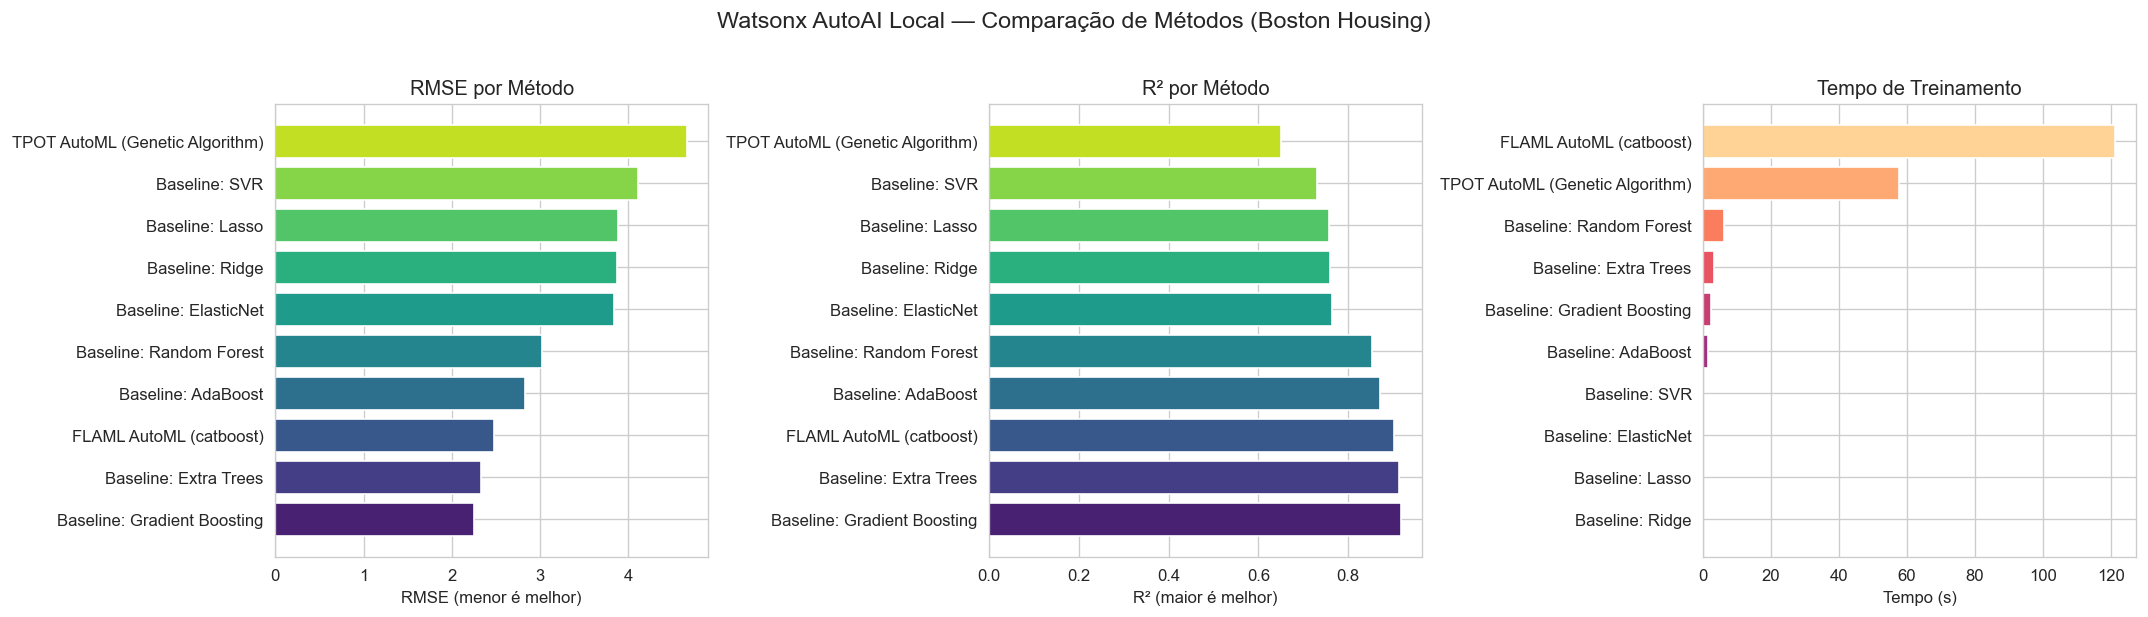

Salvo: watsonx_local_comparison.png


In [10]:
# Visualização comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_plot = df_final.sort_values('RMSE')
colors = sns.color_palette('viridis', len(df_plot))

# RMSE
axes[0].barh(df_plot['Método'], df_plot['RMSE'], color=colors)
axes[0].set_xlabel('RMSE (menor é melhor)')
axes[0].set_title('RMSE por Método')

# R²
df_plot_r2 = df_final.sort_values('R²', ascending=False)
colors_r2 = sns.color_palette('viridis', len(df_plot_r2))
axes[1].barh(df_plot_r2['Método'], df_plot_r2['R²'], color=colors_r2)
axes[1].set_xlabel('R² (maior é melhor)')
axes[1].set_title('R² por Método')

# Tempo
df_plot_time = df_final.sort_values('Tempo (s)')
colors_time = sns.color_palette('magma', len(df_plot_time))
axes[2].barh(df_plot_time['Método'], df_plot_time['Tempo (s)'], color=colors_time)
axes[2].set_xlabel('Tempo (s)')
axes[2].set_title('Tempo de Treinamento')

plt.suptitle('Watsonx AutoAI Local — Comparação de Métodos (Boston Housing)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('watsonx_local_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Salvo: watsonx_local_comparison.png')

## 6. Conclusões e Equivalência com Watsonx

### O que foi reproduzido localmente

| Etapa Watsonx AutoAI | Equivalente Local | Status |
|---|---|---|
| Carregamento de dados | scikit-learn / OpenML | Funcional |
| Pré-processamento | StandardScaler (Pipeline) | Funcional |
| Seleção de algoritmos | FLAML / TPOT / Manual | Funcional |
| Otimização de hiperparâmetros | FLAML (Bayesian) / TPOT (Genético) | Funcional |
| Ranking de pipelines | DataFrame ordenado por RMSE | Funcional |
| Tracking de experimentos | MLflow local | Funcional |
| Deploy como web service | Flask / FastAPI (separado) | Possível |

### Vantagens do setup local

1. **Sem custo** — roda 100% offline, sem credenciais cloud
2. **Reprodutibilidade** — seeds fixas, ambiente controlado
3. **Privacidade** — dados nunca saem da máquina
4. **Customização total** — controle completo de cada etapa

### Desvantagens vs Watsonx

1. **Sem escalabilidade cloud** — limitado à CPU/RAM local
2. **Sem Snap ML** — IBM Snap ML tem otimizações específicas de hardware
3. **Sem deploy automático** — Watsonx cria endpoints REST automaticamente
4. **Sem AutoAI visual** — Watsonx tem interface drag-and-drop